# Lab 1 Part A: OOP Search Algorithms for Drone Pathfinding

**Duration:** 1 week  
**Course topic:** Uninformed Search and Problem Formulation  
**Algorithms:** BFS, DFS, DLS, and IDS  
**Programming style:** Object-Oriented Python

---

## Scenario

You are programming the pathfinding logic of an autonomous drone used for environmental monitoring. The drone surveys difficult terrain to detect environmental degradation, such as illegal small-scale mining activities.

The drone must navigate from a designated **start location** to a **goal location** while avoiding obstacles such as:

- dense forests,
- water bodies,
- dangerous pits,
- restricted zones.

You will model the environment as a **search problem** and implement several search algorithms using an OOP design similar to the AIMA-style pseudocode for `BREADTH-FIRST-SEARCH(problem)` and `EXPAND(problem, node)`.

The goal of this lab is not just to get a path. The goal is to understand how different search strategies behave when the same problem object is passed to them.

# Learning Objectives

By the end of this lab, you should be able to:

1. Formulate a grid navigation task as a formal search problem.
2. Explain the roles of **state**, **action**, **result**, **path cost**, **frontier**, and **reached/explored set**.
3. Implement a reusable `Problem` interface and a `Node` class.
4. Implement and compare:
   - Breadth-First Search (BFS),
   - Depth-First Search (DFS),
   - Depth-Limited Search (DLS),
   - Iterative Deepening Search (IDS).
5. Evaluate algorithms using:
   - solution depth,
   - path cost,
   - number of nodes expanded,
   - maximum frontier/stack size,
   - completeness and optimality.
6. Explain when BFS, DFS, DLS, and IDS are complete or optimal on an unweighted grid.


# Submission Instructions

Complete all code cells marked with `TODO`.

Your final notebook must include:

1. Completed implementations of `GridProblem`, `expand`, BFS, DFS, DLS, and IDS.
2. Output tables comparing the algorithms.
3. Visualisations of at least two solution paths.
4. Answers to all reflection questions.
5. At least two additional maps created by you.
6. An **AI Use Declaration**, whether or not you used an AI tool.

Save your completed notebook as:

```text
FirstName_LastName_Lab_1A.ipynb
```

---

## GitHub Submission

You are required to submit your work through GitHub.

1. Create a GitHub repository for this lab.
2. Add your completed notebook to the repository.
3. Add your **AI Use Declaration** to the repository. This may be included inside the notebook or added as a separate file named `AI_USE_DECLARATION.md`.
4. Commit and push your final solution to GitHub.
5. Make sure the repository is **public** so that it can be accessed and graded.
6. Submit the **GitHub repository link** on Canvas.

Do **not** submit only the `.ipynb` file on Canvas. Canvas should contain the link to your public GitHub repository.

---

## AI Use Declaration Requirement

If you use any AI tool while completing this lab, you must declare it clearly. Examples of AI tools include ChatGPT, Claude, Gemini, Copilot, Perplexity, CodeWhisperer, or any other AI coding or writing assistant.

Your AI use must **not exceed 25% of the entire work**. The main implementation, debugging, explanation, testing, and final decisions must be your own.

Your declaration must include:

1. The **name of the AI tool** used.
2. The **purpose** for which it was used.
3. The **prompts or instructions** given to the tool, where applicable.
4. The **specific parts of the work influenced** by the tool.
5. A short explanation of how you **verified, edited, corrected, tested, or improved** the AI-generated output.

If you did not use any AI tool, write:

```text
I did not use any AI tool to complete this lab.
```

### Attachment of AI Output

Where required by the lecturer, you must attach evidence of AI use. Evidence may include:

- AI-generated drafts,
- prompt history,
- screenshots,
- exported conversations,
- AI-generated code snippets,
- revised versions showing your own input and improvements.

The evidence should make it clear what the AI produced and what you personally changed, tested, corrected, or improved.


---

## Final Submission Checklist

Before submitting, confirm that:

- your notebook opens correctly on GitHub,
- all completed code cells are visible,
- the notebook runs from top to bottom without errors,
- your answers to the reflection questions are included,
- your AI Use Declaration is included,
- any required evidence of AI use is attached,
- your AI use does not exceed 25% of the entire work,
- the repository is public,
- the repository link is accessible without requiring permission.


# 0. How the OOP Design Maps to Search Pseudocode

The search pseudocode uses abstract operations such as `problem.ACTIONS(s)`, `problem.RESULT(s, action)`, and `problem.IS-GOAL(s)`.

In this notebook, these become methods of a `Problem` object.

| Search pseudocode concept | Python/OOP equivalent |
|---|---|
| `problem.INITIAL` | `problem.initial_state()` |
| `problem.IS-GOAL(s)` | `problem.is_goal(state)` |
| `problem.ACTIONS(s)` | `problem.actions(state)` |
| `problem.RESULT(s, action)` | `problem.result(state, action)` |
| `problem.ACTION-COST(s, action, s')` | `problem.action_cost(state, action, next_state)` |
| `NODE(...)` | `Node(...)` dataclass |
| `frontier` | queue, stack, priority queue, or recursion stack |
| `reached` | set or dictionary that prevents unnecessary revisiting |
| `EXPAND(problem, node)` | `SearchAlgorithm.expand(problem, node)` |

This separation is important:

> The `GridProblem` knows the drone environment.  
> The search algorithms know how to search.  
> The `Node` stores the search tree information needed to reconstruct a solution path.

# 1. Setup and Imports

Run the cell below before starting the lab.

In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 2. The Abstract `Problem` Interface

Every search problem must provide the same basic operations.

This lets us write search algorithms that do not depend on the specific problem domain.
The same BFS class should work for a drone map, a road network, a puzzle, or a game state space.

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

# 3. The `Node` Class

A state alone is not enough to reconstruct the solution.

A `Node` stores:

- the current state,
- the parent node,
- the action that generated the node,
- the path cost from the start state,
- the depth of the node in the search tree.

This matches the pseudocode:

```text
NODE(STATE=s', PARENT=node, ACTION=action, PATH-COST=cost)
```

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

# 4. Helper Functions

These helper functions are provided for you.

You will use them to:

- reconstruct paths,
- check for cycles on a single path,
- convert search results into a table.

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

# 5. Implementing the Grid Search Problem

In this lab, a state is represented as a tuple:

```python
(row, col)
```

For example:

```python
(0, 0)
```

means row 0, column 0.

The grid uses:

| Cell value | Meaning |
|---|---|
| `0` | Free cell |
| `1` | Obstacle |

The actions are movement directions:

```python
"UP", "DOWN", "LEFT", "RIGHT"
```

Your `GridProblem.actions(state)` method should return only the movements that are legal from the current state.
A move is legal only if the resulting cell is:

1. inside the grid,
2. not an obstacle.

In [5]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1: - DONE
        # Return True if state is equal to the goal state.
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2: - DONE
        # Return a list of legal action names.

        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []

        row, col = state  # Unpacking the current state

        # 2. For each action in MOVES:
        #   a. Compute the neighbour cell.
        for action in MOVES:
            dr, dc = MOVES[action]
            n_row, n_col = row + dr, col + dc

            # b. Check that it is in bounds.
            #  c. Check that it is free.
            # d. If valid, add the action name to legal_actions.

            if self.in_bounds((n_row, n_col)) and self.is_free((n_row, n_col)):
                legal_actions.append(action)

        # 3. Return legal_actions.
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3: - DONE
        # Return the next state after applying action to state.

        row, col = state
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4: - DONE
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1


## 5.1 Self-Check for `GridProblem`

Run this after completing `GridProblem`.

The test grid is:

```text
S . .
# # .
. . G
```

Expected behaviour:

- Start: `(0, 0)`
- Goal: `(2, 2)`
- From `(0, 0)`, the only legal action is `"RIGHT"`
- Applying `"RIGHT"` from `(0, 0)` gives `(0, 1)`

In [6]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


# 6. Sample Drone Map

The map below is provided so your lab can run without depending on an internet connection.

You may still create your own maps later.

In [7]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

# 7. Visualisation Helper

The function below plots:

- obstacles as dark cells,
- the start position,
- the goal position,
- the solution path.

You do not need to modify this function.

In [8]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

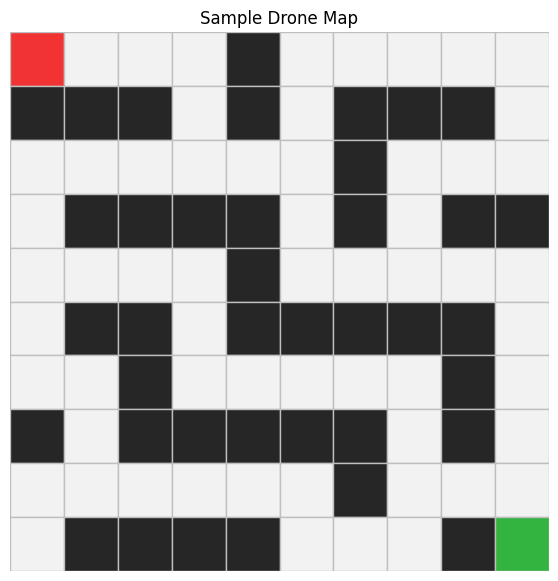

In [9]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

# 8. The Shared `expand` Method

The pseudocode has a separate `EXPAND(problem, node)` function.

In this OOP design, all search algorithms inherit a common `expand` method.

Complete this method once, then reuse it in BFS, DFS, DLS, and IDS.

The method should:

1. get the current state from the node,
2. ask the problem for legal actions,
3. generate the resulting child state for each action,
4. compute the new path cost,
5. yield a new `Node`.

In [10]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5: - DONE
        # Implement the AIMA-style EXPAND(problem, node).
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)

        state = node.state

        for action in problem.actions(state):
            s_prime = problem.result(state, action)
            cost = node.path_cost + problem.action_cost(state, action, s_prime)
            yield Node(s_prime, parent=node, action=action, path_cost=cost)
        #

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

# 9. Breadth-First Search (BFS)

BFS expands nodes in order of increasing depth.

It uses a **FIFO queue**:

- add new nodes at the back,
- remove nodes from the front.

BFS is complete for finite branching factors.  
BFS is optimal when every step has the same cost.

## Your task

Complete the `BreadthFirstSearch.search` method.

## BFS Pseudocode Guide

Study this pseudocode before completing the BFS code cell below. Try to match each pseudocode line to a Python statement in your implementation.

```text
BREADTH-FIRST-SEARCH(problem)
    node ← NODE(problem.INITIAL)

    if problem.IS-GOAL(node.STATE) then
        return node

    frontier ← a FIFO queue with node as an element
    reached ← {problem.INITIAL}

    while frontier is not empty do
        node ← POP(frontier)          // remove from the front of the queue

        for each child in EXPAND(problem, node) do
            s ← child.STATE

            if problem.IS-GOAL(s) then
                return child

            if s is not in reached then
                add s to reached
                add child to frontier // add to the back of the queue

    return failure
```

**Python structure to think about:** BFS uses `deque`, `popleft()`, and `append()`.


In [11]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6 - DONE:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()

        nodes_expanded = 0
        max_frontier_size = 1

        initial_node = Node(problem.initial_state())

        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )

        frontier = deque([initial_node])

        reached = {initial_node.state}

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                state = child.state

                if problem.is_goal(state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                if state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

# 10. Depth-First Search (DFS)

DFS expands the deepest node on the frontier first.

It uses a **LIFO stack**:

- push new nodes onto the stack,
- pop the most recently added node.

DFS is memory-efficient in some cases, but it is not generally optimal.
In infinite state spaces or spaces with cycles, DFS can fail to terminate unless cycle handling or depth limits are used.

## Your task

Complete the `DepthFirstSearch.search` method.

## DFS Pseudocode Guide

Study this pseudocode before completing the DFS code cell below. Notice that DFS uses a stack instead of a queue.

```text
DEPTH-FIRST-SEARCH(problem)
    node ← NODE(problem.INITIAL)

    if problem.IS-GOAL(node.STATE) then
        return node

    frontier ← a LIFO stack with node as an element
    reached ← {problem.INITIAL}

    while frontier is not empty do
        node ← POP(frontier)          // remove from the top/end of the stack

        for each child in EXPAND(problem, node) do
            s ← child.STATE

            if problem.IS-GOAL(s) then
                return child

            if s is not in reached then
                add s to reached
                PUSH child onto frontier

    return failure
```

**Python structure to think about:** DFS can use a normal list, with `append()` to push and `pop()` to remove the most recently added node.


In [12]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7: - DONE
        # Implement DFS graph search using a stack.
        #

        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.

        nodes_expanded = 0
        max_frontier_size = 1

        initial_node = Node(problem.initial_state())

        frontier = [initial_node]
        reached = {initial_node.state}

        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=initial_node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=1,
            )

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                state = child.state

                if problem.is_goal(state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                if state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

# 11. Depth-Limited Search (DLS)

Depth-Limited Search is DFS with a maximum depth limit.

DLS is useful when:

- the state space may be very deep,
- DFS may go down an unhelpful branch,
- we want to restrict the search depth.

DLS can return three statuses:

| Status | Meaning |
|---|---|
| `"success"` | A solution was found |
| `"cutoff"` | The search reached the depth limit before proving failure |
| `"failure"` | No solution exists within the explored part and no cutoff occurred |

## Important note about repeated states

For DLS, use **path-cycle checking** rather than a global reached set.  
This means you should avoid adding a child if its state already appears on the current path from the root to the current node.

Use this helper:

```python
state_is_on_path(node, child.state)
```

## DLS Pseudocode Guide

Study this pseudocode before completing the recursive DLS code cell below. DLS behaves like DFS, but it refuses to search beyond a given depth limit.

```text
DEPTH-LIMITED-SEARCH(problem, limit)
    node ← NODE(problem.INITIAL)
    return RECURSIVE-DLS(node, problem, limit)

RECURSIVE-DLS(node, problem, limit)
    if problem.IS-GOAL(node.STATE) then
        return node, success

    else if node.DEPTH ≥ limit then
        return null, cutoff

    else
        cutoff_occurred ← false

        for each child in EXPAND(problem, node) do
            if child.STATE is already on the current path then
                skip this child

            result, status ← RECURSIVE-DLS(child, problem, limit)

            if status = success then
                return result, success

            else if status = cutoff then
                cutoff_occurred ← true

        if cutoff_occurred then
            return null, cutoff
        else
            return null, failure
```

**Python structure to think about:** DLS is naturally implemented using a helper method such as `_recursive_dls(...)`.


In [13]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
    ) -> Tuple[Optional[Node], str]:
        # TODO 8: - DONE
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")

        metrics["max_stack_size"] = max(metrics["max_stack_size"], node.depth + 1)

        if problem.is_goal(node.state):
            return (node, "success")

        elif node.depth >= limit:
            return (None, "cutoff")

        else:
            metrics["nodes_expanded"] += 1
            cutoff_occured = False

            for child in self.expand(problem, node):
                if state_is_on_path(node, child.state):
                    continue

                result, status = self._recursive_dls(problem, child, limit, metrics)

                if status == "success":
                    return (result, "success")

                if status == "cutoff":
                    cutoff_occured = True

            if cutoff_occured:
                return (None, "cutoff")

            else:
                return (None, "failure")


# 12. Iterative Deepening Search (IDS)

IDS repeatedly runs DLS with increasing depth limits.

It tries:

```text
limit = 0
limit = 1
limit = 2
limit = 3
...
```

IDS combines some strengths of BFS and DFS:

- It is complete for finite branching factor search spaces.
- It is optimal when step costs are uniform.
- It uses memory similar to DFS.
- It may expand shallow nodes several times.

## Your task

Complete `IterativeDeepeningSearch.search`.

## IDS Pseudocode Guide

Study this pseudocode before completing the IDS code cell below. IDS repeatedly calls DLS with increasing limits.

```text
ITERATIVE-DEEPENING-SEARCH(problem, max_depth)
    for limit from 0 to max_depth do
        result, status ← DEPTH-LIMITED-SEARCH(problem, limit)

        record the limit and status in the iteration log

        if status = success then
            return result

        else if status = failure then
            return failure

    return cutoff
```

**Python structure to think about:** IDS should create a `DepthLimitedSearch` object and call `dls.search(problem, limit=limit)` inside a loop.


In [14]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9: - DONE
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)
        total_nodes_expanded = 0
        max_stack_size = 1

        iteration_log = []

        for limit in range(0, max_depth + 1):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)

            iteration_log.append((limit, result.status))

            total_nodes_expanded += result.nodes_expanded
            max_stack_size = max(max_stack_size, result.max_frontier_size)

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    iterations=iteration_log,
                )

            if result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    iterations=iteration_log,
                )

        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            iterations=iteration_log,
        )

# 13. Run the Algorithms on the Sample Map

Complete all algorithm classes before running this section.

For DLS, choose a depth limit. Try a limit that is too small first, then a limit that is large enough.

In [15]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,18.0,18.0,18,4,21
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,NaN,18.0,18.0,356,19,0


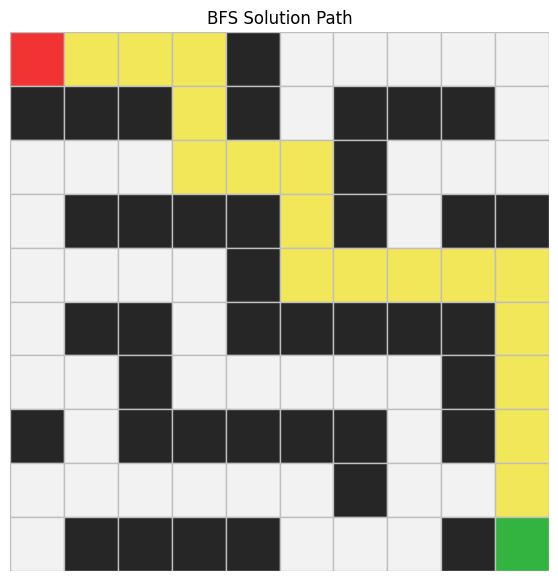

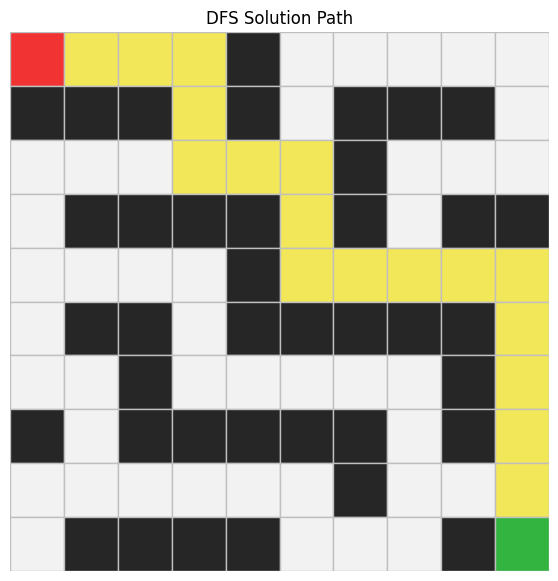

In [16]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)


# 14. Create Your Own Maps

Create at least **two additional maps**.

Your maps should be meaningfully different. For example:

1. A map with a long narrow corridor.
2. A map with many dead ends.
3. A map where DFS is likely to enter dead ends before finding the goal.
4. A larger map, such as 15 × 15 or 20 × 20.

For each map:

- run BFS, DFS, DLS, and IDS,
- record the metrics,
- visualise at least one solution path,
- write a short interpretation.


In [17]:
# TODO 10: - DONE
# Create your first custom map here.

custom_grid_1 = np.ones((20, 20), dtype=np.int8)  # Creating a 20x20 obstacle grid with numpy

# Carving out a start room at the start of the top-left
custom_grid_1[1:5, 1:5] = 0

# Carving out a long narrow corridor
custom_grid_1[3, 5:19] = 0

# Carving out a dead end branch off the corridor (stopping at column 10, and row 9)
custom_grid_1[4:10, 10] = 0

# Carving out a larger room at the botttom right (rows 12-17 and columns 12-17)
custom_grid_1[12:18, 12:18] = 0

# Connect the long corridor to the end room (vertical connector at column 18)
custom_grid_1[4:13, 18] = 0

# Define the start and goal as free-cell coordinates
custom_start_1 = (1, 1)
custom_goal_1 = (17, 17)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,34.0,34.0,56,5,60
1,DFS,success,NaN,44.0,44.0,44,17,60
2,DLS,cutoff,20.0,NaN,NaN,3915,21,0
3,IDS,success,NaN,34.0,34.0,100127,35,0


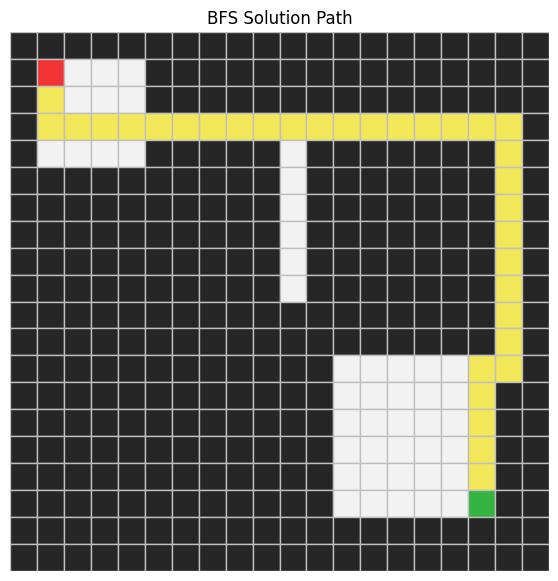

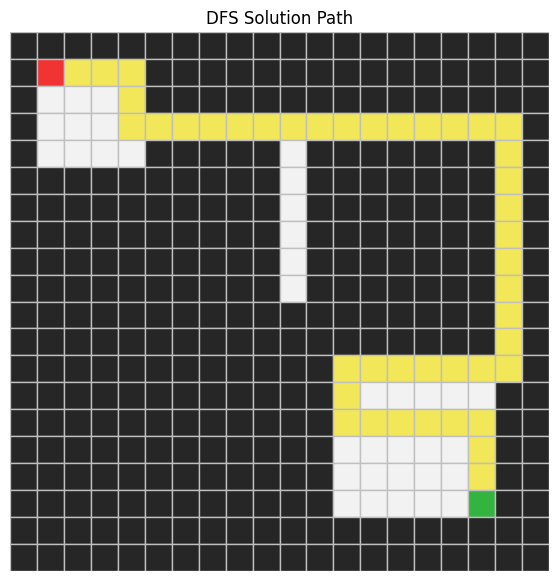

In [18]:
# Visualsing the solution paths on the custom maps (20 x 20)

bfs_result = custom_results_1[0]
dfs_result = custom_results_1[1]

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=dfs_result.path,
    title="DFS Solution Path",
)


In [19]:
# TODO 11 - DONE:
# Create your second custom map here.

custom_grid_2 = np.ones((15, 15), dtype=np.int8) # Creating a 15x15 obstacle grid with numpy

# Carve out a starting room near the top-left corner
custom_grid_2[1:5, 1:5] = 0

# Create a horizontal corridor from the starting room
custom_grid_2[3, 5:11] = 0

# Create a vertical corridor leading toward the bottom
custom_grid_2[4:14, 10] = 0

# Connect the vertical corridor to the goal
custom_grid_2[13, 10:14] = 0

# Create a separate dead-end corridor along the right edge
custom_grid_2[4:13, 14] = 0

# Define the start and goal as free-cell coordinates
custom_start_2 = (1, 1)
custom_goal_2 = (13, 13)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=25),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,24,24,34,4,34
1,DFS,success,NaN,24,24,24,6,29
2,DLS,success,25.0,24,24,1202,26,0
3,IDS,success,NaN,24,24,40181,25,0


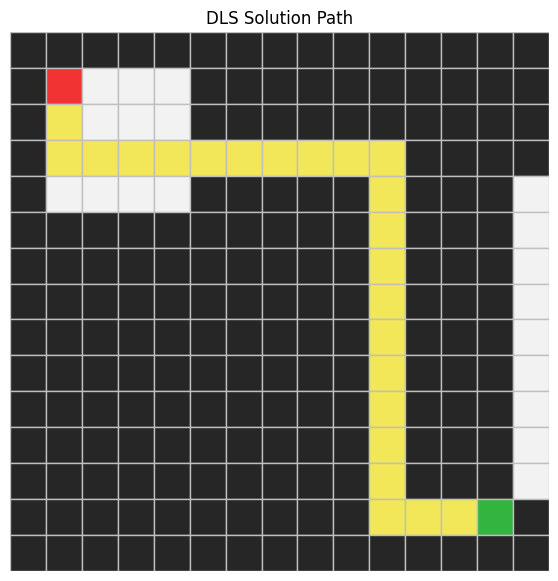

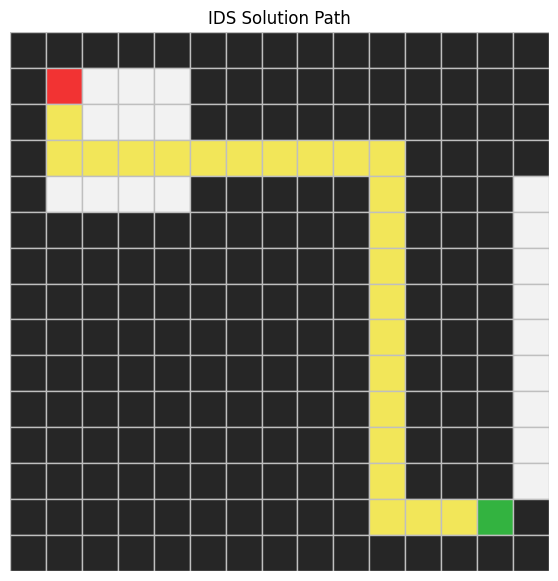

In [20]:
# Visualsing the solution paths on the custom maps (15 x 15)

dls_result = custom_results_2[2]
ids_result = custom_results_2[3]


plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=dls_result.path,
    title="DLS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=ids_result.path,
    title="IDS Solution Path",
)


# 15. Reflection Questions

Answer the questions below in markdown cells.

## 15.1 Problem Formulation

1. What is a state in this lab?

   In this lab, a state is a tuple that represents a cell on the problem grid.



2. What is an action?

   An action is a defined operation that transitions a state to another state. 



3. What does the `result` function do?

   The `result` function returns the new state after applying an action to the current state.



4. Why is it useful to separate the problem definition from the search algorithm?


   Separating the problem definition from the search algorithm prioritises modularity, allowing different problems to be solved by the same algorithm.


## 15.2 BFS

1. Why does BFS use a FIFO queue?

    BFS uses a FIFO queue since with this algorithm, the shallowest nodes are expanded before going to the ones further away. Nodes are inserted at the back and removed from the front, all nodes on one level are processed before touching a node on the next level.


2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid?

   BFS explores nodes in increasing depth order, so on an unweighted grid the first goal it reaches has the fewest number of moves. Since every move has the same cost, that path is also the lowest-cost path.
   
   

3. What role does the `reached` set play in BFS?

   The `reached` set in BFS tracks all the states that have been reached during the search. It keeps track in order to avoid cycles. 


## 15.3 DFS

1. Why does DFS use a stack?

   DFS uses a stack since the deepest node is expanded first. Stacks have the LIFO (last in, first out) characteristic, meaning the recently added node will be the one removed first for processing.


2. Is DFS guaranteed to find the shortest path? Explain.

   It is not guaranteed. DFS explores as deep as possible before backtracking. The first path could be a long path, filled with detours which it has to go through before taking a closer path after backtracking. 



3. Under what conditions can DFS use less memory than BFS?


   DFS can use less memory than BFS where solutions are located deep. If target nodes are located far away from the root node, DFS can go down a single branch, find the solution and terminate early. Also, as DFS goes deep down a path, it saves nodes along that path. As soon as it hits a dead end, the leaf nodes are discarded before backtracking, meaning it never has a massive pool of nodes stored in memory. 



4. Under what conditions can DFS perform badly?

   DFS can perform badly if the branching factor/state space is infinite, the algorithm can keep going down into a rabbit hole with no solution, if no cycle-limit or depth-limit has been set. The same happens with shallow targets, that are located a few levels down from the root node since it explores the maximum depth of the first branch it visits before backtracking to the shallow one.


## 15.4 DLS

1. What happens when the depth limit is too small?

   When a depth limit is too small, the algorithm becomes incomplete. This means it will fail to find the goal state, even if a valid solution exists within the search tree, as the search stops before it gets to that level. 



2. What is the meaning of `"cutoff"`?

    `"cutoff"` means that the search reached the depth limit before proving failure. 



3. How is DLS different from ordinary DFS?

   DLS is different from ordinary DFS as it sets a limit to the depth inquiry. Since DFS goes deeper in levels to expand, DLS sets a limit to how far the search can go. 



4. Why do we use path-cycle checking in DLS?

   Since DLS involves moving deeper into a tree before backtracking, path-cycle checking is there in order to prevent cycles or redundant computations, as the search could keep going through the same path.


## 15.5 IDS

1. Why does IDS repeat DLS with increasing limits?


   IDS repeats DLS with increasing limits as with DLS, the limit could prevent the search from finding a solution even though a valid solution could exist in the tree. 


2. Why can IDS be complete even though DLS with a small limit is not?


   This is because IDS systematically increases the limit with each iteration, eventually reaching the exact depth of the shallowest goal. Whereas with DLS, the search gets stuck if it exceeds the depth limit, which leads to missing the solution entirely.



3. Why does IDS use less memory than BFS?


   IDS uses less memory than BFS as it does not store all the nodes of a level in memory like BFS does. Instead, it stores only the nodes that are present along the active path.



4. What is the cost of repeatedly searching from the root?


   Repeatedly searching from the root will mean visited nodes are not being tracked, which increases cost/time complexity to exponential levels. This causes massive redundancy since the nodes are constantly being re-evaluated. 




## 15.6 Real-World Drone Context

1. In a real drone application, what might make one route safer or more practical than another?

   A safer route might avoid buildings, trees, power lines, no-fly zones, bad weather, and crowded areas. Route length, altitude, battery use, and emergency landing options would also matter.
   

2. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.

   I would choose BFS because states are explored in increasing depth order. Therefore, the first solution it finds is guaranteed to have the lowest path cost since every move costs the same.

3. Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.

   I would pick DLS because it does not explore beyond a set limit. This can limit how deep the drone does its search, although a limit too small could cause a cutoff before finding a solution, missing the goal entirely. 

4. What limitations does this grid model have compared with real drone navigation?

   The grid represents an abstracted version of the real world, being represented by fixed free cells and obstacles. It does not take into consideration altitude, continuous movement, dynamic obstacles, weather patterns, and any other factor present in a dynamic and non-deterministic environment. A real drone would need sensors and continuous route updates. 




# 16. Final Checklist

Before submitting, confirm that:

- [x] `GridProblem` is complete.
- [x] `SearchAlgorithm.expand` is complete.
- [x] BFS is complete.
- [x] DFS is complete.
- [x] DLS is complete.
- [x] IDS is complete.
- [x] You generated comparison tables.
- [x] You visualised solution paths.
- [x] You created at least two custom maps.
- [x] You answered all reflection questions.
- [x] Your notebook filename follows the required format.
